# CS 432 Databases — Assignment 2
# B+ Tree Database Management System: Implementation, Analysis & Visualisation

**Course:** CS 432 – Databases  
**Track:** 1 | **Assignment:** 2

---

## Table of Contents
1. [Introduction](#1-introduction)
2. [Implementation](#2-implementation)
3. [Performance Analysis](#3-performance-analysis)
4. [Visualisation](#4-visualisation)
5. [Performance Testing & Plots](#5-performance-testing--plots)
6. [Video Demonstration](#6-video-demonstration)
7. [Conclusion](#7-conclusion)

---
## 1. Introduction

### Problem Statement

Modern database systems must handle millions of records with response times measured in milliseconds. A naive approach — storing records in an unsorted list — gives **O(n)** time for search, range queries, and deletion. As dataset size grows, this linear cost becomes a hard bottleneck.

### Proposed Solution: B+ Tree DBMS

A **B+ Tree** is the backbone indexing structure of virtually every production DBMS (MySQL InnoDB, PostgreSQL, Oracle DB). Its design guarantees:

| Property | Detail |
|---|---|
| All data stored at leaves | Internal nodes are pure routing — only leaf nodes hold actual records |
| Sorted leaf linked list | Leaves are chained via `next_leaf` pointers, enabling O(k) range scans |
| Perfectly balanced height | Every leaf sits at the same depth → O(log n) for all operations |
| Order `m` capacity rule | Each non-root node holds between ⌈m/2⌉−1 and m−1 keys |

### Objectives
1. Implement a complete B+ Tree supporting insert, delete, search, range query, and update.
2. Benchmark it against a brute-force list-based database (`BruteForceDB`).
3. Visualise the tree structure using Graphviz at different stages.
4. Present findings through Matplotlib performance plots and benchmark tables.

---
## 2. Implementation

### 2.1 Imports

In [64]:
from graphviz import Digraph
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

print("All imports successful.")

All imports successful.


### 2.2 BPlusTreeNode Class

The `BPlusTreeNode` class is the fundamental building block of the tree. Each node stores:

- **`keys`** — a sorted list used for routing (internal nodes) or record indexing (leaf nodes).
- **`values`** — actual database records; populated **only** in leaf nodes.
- **`children`** — pointers to child nodes; populated **only** in internal nodes.
- **`next_leaf`** — pointer to the right sibling leaf, forming the scan chain used by range queries.

Key methods and their roles:

| Method | Role |
|---|---|
| `is_full()` | Returns `True` when `len(keys) == order − 1`, signalling a split is needed |
| `insert_at_leaf()` | Inserts key/value in sorted position; silently updates on duplicate |
| `split_node()` | Splits a full node — **copies** median key for leaf splits, **pushes** it up for internal splits |
| `find_child_index()` | Routes a key to the correct child subtree in an internal node |
| `get_value()` | Point lookup within a leaf node |
| `remove_from_leaf()` | Deletes a key/value pair from a leaf |

In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 1 — BPlusTreeNode
# ─────────────────────────────────────────────────────────────────────────────

class BPlusTreeNode:
    def __init__(self, order, is_leaf=False):
        # 'order' dictates our maximum capacity (maximum number of children)
        self.order = order
        self.is_leaf = is_leaf

        # Every node, regardless of type, needs keys to maintain sorted order
        self.keys = []

        # Leaves store the actual database records/values
        self.values = []
        # Leaves link to their right neighbor for fast range queries
        self.next_leaf = None

        # Internal nodes don't store data; they store pointers to other nodes
        self.children = []

    def is_full(self):
        """Check if this node has hit its key limit."""
        # By definition, a B+ tree node of a given order 'm' can hold at most 'm - 1' keys
        return len(self.keys) >= self.order - 1

    def insert_at_leaf(self, key, value):
        """
        Inserts a key and its corresponding value into a leaf node.
        We must ensure the keys stay in strictly increasing order.
        """
        # Safety check: we should only be doing this in a leaf!
        if not self.is_leaf:
            raise ValueError("Cannot insert data into an internal routing node.")

        # Walk through the keys to find the exact right spot
        idx = 0
        while idx < len(self.keys) and key > self.keys[idx]:
            idx += 1

        # Handle duplicates (Updates)
        # If the key is already here, we just update the existing record
        if idx < len(self.keys) and self.keys[idx] == key:
            self.values[idx] = value
            return False  # Returning False lets our main tree know it was just an update

        # Insert the brand new key and value at the found index
        self.keys.insert(idx, key)
        self.values.insert(idx, value)
        return True  # Returning True means the node grew in size

    def find_child_index(self, key):
        """
        For internal nodes, this acts as a traffic director.
        It looks at the keys and figures out which child pointer to follow down the tree.
        """
        # Safety check: leaves don't have children!
        if self.is_leaf:
            raise ValueError("Leaf nodes do not have children to search through.")

        idx = 0
        # We move right as long as the target key is greater than or equal to the current key
        while idx < len(self.keys) and key >= self.keys[idx]:
            idx += 1

        # This index perfectly matches the position in the self.children list
        return idx

    def split_node(self):
        """
        Splits a full node into two, returning the key to be promoted
        and the newly created right-sibling node.
        """
        mid_index = len(self.keys) // 2

        # Create the new right-hand buddy node. It shares the same leaf status.
        right_node = BPlusTreeNode(self.order, is_leaf=self.is_leaf)

        if self.is_leaf:
            # LEAF NODE SPLIT
            # Give the right node the second half of the keys and values
            right_node.keys = self.keys[mid_index:]
            right_node.values = self.values[mid_index:]

            # Keep the first half for the current node
            self.keys = self.keys[:mid_index]
            self.values = self.values[:mid_index]

            # Re-wire the linked list so range queries still work seamlessly
            right_node.next_leaf = self.next_leaf
            self.next_leaf = right_node

            # For leaves, we COPY the first key of the right node to push up
            promoted_key = right_node.keys[0]

        else:
            # INTERNAL NODE SPLIT
            # The middle key is removed entirely from this level to be pushed up
            promoted_key = self.keys[mid_index]

            # Give the right node the keys and children AFTER the middle key
            right_node.keys = self.keys[mid_index + 1:]
            right_node.children = self.children[mid_index + 1:]

            # Keep the keys and children BEFORE the middle key for the current node
            self.keys = self.keys[:mid_index]
            self.children = self.children[:mid_index + 1]

        return promoted_key, right_node

    def get_value(self, key):
        """
        Searches this leaf node for a specific key and returns its value.
        """
        # Safety check: internal nodes don't hold actual data values
        if not self.is_leaf:
            return None

        # Scan through the keys. If we find a match, return the value at the exact same index.
        for idx, k in enumerate(self.keys):
            if k == key:
                return self.values[idx]

        # If we check all keys and don't find it, it doesn't exist here
        return None

    def remove_from_leaf(self, key):
        """
        Finds a key in this leaf node and removes both it and its corresponding value.
        """
        # Safety check: we only delete raw data from leaves
        if not self.is_leaf:
            return False

        for idx, k in enumerate(self.keys):
            if k == key:
                # Pop removes the item at the specific index from the list
                self.keys.pop(idx)
                self.values.pop(idx)
                return True  # Deletion successful

        return False  # Key wasn't found


print("BPlusTreeNode defined.")

BPlusTreeNode defined.


### 2.3 BPlusTree Class

The `BPlusTree` class manages the root pointer and exposes the full public API. The table below summarises each operation and its time complexity:

| Method | Time Complexity | Core Strategy |
|---|---|---|
| `insert(key, value)` | O(log n) | Pre-emptive child splitting on the way **down** |
| `search(key)` | O(log n) | Traverse internal nodes, point lookup at leaf |
| `range_query(start, end)` | O(log n + k) | Descend once to start leaf, walk `next_leaf` chain |
| `delete(key)` | O(log n) | Remove from leaf; repair underflow on the way **back up** |
| `update(key, value)` | O(log n) | Descend to leaf, overwrite value in place |
| `get_all()` | O(n) | Drop to leftmost leaf, walk entire chain |
| `visualize_tree()` | O(n) | Graphviz HTML-record rendering with leaf chain arrows |

In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 1 — BPlusTree
# ─────────────────────────────────────────────────────────────────────────────

class BPlusTree:
    def __init__(self, order=4):
        self.order = order
        # The tree always starts with a single, empty leaf node acting as the root
        self.root = BPlusTreeNode(order=self.order, is_leaf=True)

    def search(self, key):
        """
        Exact Search: Returns the value for a given key, or None if not found.
        """
        current_node = self.root

        # Drill down through internal nodes until we hit a leaf
        while not current_node.is_leaf:
            # Our smart node tells us exactly which child pointer to follow
            idx = current_node.find_child_index(key)
            current_node = current_node.children[idx]

        # Now we are at the correct leaf, just ask the leaf for the value
        return current_node.get_value(key)

    def range_query(self, start_key, end_key):
        """
        Range Query: Returns a list of (key, value) tuples within the range.
        This takes advantage of the linked list connecting our leaf nodes!
        """
        results = []
        current_node = self.root

        # Drill down to find the leaf where the `start_key` belongs
        while not current_node.is_leaf:
            idx = current_node.find_child_index(start_key)
            current_node = current_node.children[idx]

        # Surf the linked list of leaves!
        while current_node is not None:
            # Check every key in the current leaf
            for i, k in enumerate(current_node.keys):
                if start_key <= k <= end_key:
                    results.append((k, current_node.values[i]))
                elif k > end_key:
                    # Since keys are sorted, once we pass end_key, we are completely done!
                    return results

            # Jump to the right neighbor using the pointer we set up during splits
            current_node = current_node.next_leaf

        return results

    def insert(self, key, value):
        """
        The main entry point for adding new data.
        It handles the special case where the very top of the tree (the root) is full.
        """
        # If the root has hit its capacity, the entire tree must grow one level taller
        if self.root.is_full():
            # Create a new, empty internal node to become the new root
            new_root = BPlusTreeNode(self.order, is_leaf=False)

            # The old root becomes the first child of this new root
            new_root.children.append(self.root)

            # Force the old root to split. It gives us a key to pull up and a new right child.
            promoted_key, right_child = self.root.split_node()

            # Slot the promoted key and the new right child into our new root
            new_root.keys.append(promoted_key)
            new_root.children.append(right_child)

            # Officially update the tree's root pointer
            self.root = new_root

        # Now that we are sure the root has breathing room, we start the descent
        self._insert_non_full(self.root, key, value)

    def _insert_non_full(self, current_node, key, value):
        """
        A recursive helper that navigates down the tree.
        It splits any full child nodes it encounters ON THE WAY DOWN to prevent bottlenecks.
        """
        if current_node.is_leaf:
            # Base Case: We hit the bottom! Drop the data in.
            current_node.insert_at_leaf(key, value)
        else:
            # Recursive Case: We are in an internal node. Find which path to take.
            idx = current_node.find_child_index(key)
            child_node = current_node.children[idx]

            # Pre-emptive split: If the child we are about to visit is full, split it FIRST.
            if child_node.is_full():
                promoted_key, right_child = child_node.split_node()

                # Insert the promoted key and new child pointer into the current internal node
                current_node.keys.insert(idx, promoted_key)
                current_node.children.insert(idx + 1, right_child)

                # Because we just split the child, the key we are trying to insert might
                # actually belong in the newly created right child. We need to check!
                if key >= current_node.keys[idx]:
                    idx += 1
                    child_node = current_node.children[idx]

            # Now safely move down to the (guaranteed not-full) child
            self._insert_non_full(child_node, key, value)

    def get_all(self):
        """
        Returns every single (key, value) pair in the database index.
        This uses an in-order traversal by riding the leaf linked-list.
        """
        results = []
        current_node = self.root

        # Step 1: Drop straight down the far-left edge of the tree
        while not current_node.is_leaf:
            current_node = current_node.children[0]

        # Step 2: Surf the linked list from left to right!
        while current_node is not None:
            for i in range(len(current_node.keys)):
                results.append((current_node.keys[i], current_node.values[i]))
            current_node = current_node.next_leaf

        return results

    def visualize_tree(self, title='B+ Tree'):
        """
        Pure-matplotlib visualiser that replicates the original Graphviz HTML-record style:
          - Internal nodes: alternating tan pointer-slots (#F0E6D3) and orange key-cells (#FAD7A0)
          - Leaf nodes: rounded blue key-cells (#1A5276 text on white)
          - Solid dark arrows: parent pointer-slot -> child node
          - Dashed green arrows: next_leaf linked-list chain
        """
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches
        from matplotlib.patches import FancyArrowPatch
        from collections import deque

        # ── 1. BFS: collect levels ────────────────────────────────────────────
        levels = []
        queue  = deque([(self.root, 0)])
        while queue:
            node, d = queue.popleft()
            while len(levels) <= d:
                levels.append([])
            levels[d].append(node)
            if not node.is_leaf:
                for child in node.children:
                    queue.append((child, d + 1))

        num_levels = len(levels)
        max_nodes  = max(len(lvl) for lvl in levels)

        # ── 2. Layout constants (data-coords, not axes-fraction) ──────────────
        CELL_W   = 0.7    # width of one key cell
        PTR_W    = 0.35   # width of a pointer slot cell
        CELL_H   = 0.5    # height of all cells
        Y_GAP    = 2.0    # vertical gap between levels
        X_MARGIN = 1.5

        # estimate canvas width from the widest level
        def node_width(node):
            n = len(node.keys)
            if node.is_leaf:
                return max(n, 1) * CELL_W
            else:
                return n * (CELL_W + PTR_W) + PTR_W

        max_level_w = max(
            sum(node_width(nd) for nd in lvl) + (len(lvl) - 1) * X_MARGIN
            for lvl in levels
        )
        canvas_w = max(max_level_w + 2 * X_MARGIN, 8)
        canvas_h = num_levels * (CELL_H + Y_GAP) + 1

        fig, ax = plt.subplots(figsize=(max(10, canvas_w * 0.9),
                                        max(4,  canvas_h * 0.85)))
        ax.set_xlim(0, canvas_w)
        ax.set_ylim(0, canvas_h)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

        node_meta = {}   # id(node) -> {'x0','y0','w','h', 'slots': [(cx,cy), ...]}

        # ── 3. Assign x positions level by level ─────────────────────────────
        for d, lvl in enumerate(levels):
            y_top   = canvas_h - 1.0 - d * (CELL_H + Y_GAP)
            widths  = [node_width(nd) for nd in lvl]
            total_w = sum(widths) + (len(lvl) - 1) * X_MARGIN
            x_start = (canvas_w - total_w) / 2

            for nd, w in zip(lvl, widths):
                node_meta[id(nd)] = {
                    'x0': x_start, 'y0': y_top - CELL_H,
                    'w': w,        'h': CELL_H,
                    'slots': []    # (cx, cy) of each child-pointer slot (internal) or key cell (leaf)
                }
                x_start += w + X_MARGIN

        # ── 4. Draw nodes ─────────────────────────────────────────────────────
        for d, lvl in enumerate(levels):
            for nd in lvl:
                m  = node_meta[id(nd)]
                x0 = m['x0']
                y0 = m['y0']

                if nd.is_leaf:
                    # ── Leaf: one rounded cell per key ────────────────────────
                    keys = nd.keys if nd.keys else ['']
                    for i, k in enumerate(keys):
                        cx = x0 + (i + 0.5) * CELL_W
                        cy = y0 + CELL_H / 2
                        rect = mpatches.FancyBboxPatch(
                            (x0 + i * CELL_W + 0.03, y0 + 0.03),
                            CELL_W - 0.06, CELL_H - 0.06,
                            boxstyle='round,pad=0.04',
                            linewidth=1.2,
                            edgecolor='#1A5276', facecolor='white',
                            zorder=3
                        )
                        ax.add_patch(rect)
                        if k != '':
                            ax.text(cx, cy, str(k),
                                    ha='center', va='center',
                                    fontsize=9, fontweight='bold',
                                    color='#1A5276', zorder=4)
                        m['slots'].append((cx, cy))   # used for leaf-chain arrows

                else:
                    # ── Internal: alternating ptr-slot | key | ptr-slot | ... ──
                    n_keys = len(nd.keys)
                    x      = x0
                    for i in range(n_keys):
                        # pointer slot
                        slot_cx = x + PTR_W / 2
                        slot_cy = y0 + CELL_H / 2
                        ax.add_patch(mpatches.Rectangle(
                            (x, y0), PTR_W, CELL_H,
                            linewidth=1, edgecolor='#7D6608',
                            facecolor='#F0E6D3', zorder=3
                        ))
                        m['slots'].append((slot_cx, slot_cy))
                        x += PTR_W
                        # key cell
                        ax.add_patch(mpatches.Rectangle(
                            (x, y0), CELL_W, CELL_H,
                            linewidth=1, edgecolor='#7D6608',
                            facecolor='#FAD7A0', zorder=3
                        ))
                        ax.text(x + CELL_W / 2, slot_cy, str(nd.keys[i]),
                                ha='center', va='center',
                                fontsize=9, fontweight='bold',
                                color='#784212', zorder=4)
                        x += CELL_W
                    # last pointer slot
                    slot_cx = x + PTR_W / 2
                    slot_cy = y0 + CELL_H / 2
                    ax.add_patch(mpatches.Rectangle(
                        (x, y0), PTR_W, CELL_H,
                        linewidth=1, edgecolor='#7D6608',
                        facecolor='#F0E6D3', zorder=3
                    ))
                    m['slots'].append((slot_cx, slot_cy))

        # ── 5. Tree edges: pointer slot -> top of child node ──────────────────
        for d, lvl in enumerate(levels[:-1]):
            for nd in lvl:
                if nd.is_leaf:
                    continue
                m = node_meta[id(nd)]
                for i, child in enumerate(nd.children):
                    if i >= len(m['slots']):
                        continue
                    sx, sy   = m['slots'][i]
                    cm       = node_meta[id(child)]
                    tx, ty   = cm['x0'] + cm['w'] / 2, cm['y0'] + cm['h']
                    ax.annotate('',
                        xy=(tx, ty), xytext=(sx, sy - CELL_H / 2 + 0.02),
                        arrowprops=dict(
                            arrowstyle='->', color='#2C3E50',
                            lw=1.4, connectionstyle='arc3,rad=0.0'
                        ), zorder=2)

        # ── 6. next_leaf chain: dashed green ─────────────────────────────────
        for nd in levels[-1]:
            if nd.next_leaf and id(nd.next_leaf) in node_meta:
                m1  = node_meta[id(nd)]
                m2  = node_meta[id(nd.next_leaf)]
                x1  = m1['x0'] + m1['w']
                y1  = m1['y0'] + m1['h'] / 2
                x2  = m2['x0']
                y2  = m2['y0'] + m2['h'] / 2
                ax.annotate('',
                    xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(
                        arrowstyle='->', color='#1D8348',
                        lw=1.3, linestyle='dashed',
                        connectionstyle='arc3,rad=-0.3'
                    ), zorder=2)

        plt.tight_layout()
        plt.show()

    def delete(self, key):
        """
        Deletes a key from the B+ tree.
        Updates the root if it becomes empty.
        Returns True if deletion succeeded, False otherwise.
        """
        if len(self.root.keys) == 0:
            return False

        # Start the recursive deletion process
        success = self._delete(self.root, key)

        # If the root is completely empty but still has a child,
        # the tree shrinks in height! We just make the child the new root.
        if len(self.root.keys) == 0 and not self.root.is_leaf:
            self.root = self.root.children[0]

        return success

    def _delete(self, current_node, key):
        """
        Recursive helper for deletion.
        Ensures all nodes maintain minimum keys after deletion.
        """
        if current_node.is_leaf:
            # Base Case: Try to remove the key directly from the leaf
            return current_node.remove_from_leaf(key)
        else:
            # Recursive Case: Find which child should contain the key and go down
            idx = current_node.find_child_index(key)
            child_node = current_node.children[idx]

            # Recursively delete from that child
            success = self._delete(child_node, key)

            # UNDERFLOW CHECK: A node must be at least half full.
            # If our child lost too many keys, we must step in and fix it.
            min_keys = self.order // 2
            if len(child_node.keys) < min_keys:
                self._fill_child(current_node, idx)

            return success

    def _fill_child(self, parent_node, idx):
        """
        Ensures child at given index has enough keys by borrowing from siblings or merging.
        """
        min_keys = self.order // 2

        # Strategy 1: Try borrowing from the LEFT sibling
        if idx > 0 and len(parent_node.children[idx - 1].keys) > min_keys:
            self._borrow_from_prev(parent_node, idx)

        # Strategy 2: Try borrowing from the RIGHT sibling
        elif idx < len(parent_node.children) - 1 and len(parent_node.children[idx + 1].keys) > min_keys:
            self._borrow_from_next(parent_node, idx)

        # Strategy 3: If siblings are also poor, we must MERGE them together
        else:
            if idx < len(parent_node.children) - 1:
                self._merge(parent_node, idx)
            else:
                self._merge(parent_node, idx - 1)

    def _borrow_from_prev(self, parent_node, idx):
        """Borrow a key from the left sibling to prevent underflow."""
        child = parent_node.children[idx]
        left_sibling = parent_node.children[idx - 1]

        if child.is_leaf:
            child.keys.insert(0, left_sibling.keys.pop())
            child.values.insert(0, left_sibling.values.pop())
            parent_node.keys[idx - 1] = child.keys[0]
        else:
            child.keys.insert(0, parent_node.keys[idx - 1])
            parent_node.keys[idx - 1] = left_sibling.keys.pop()
            child.children.insert(0, left_sibling.children.pop())

    def _borrow_from_next(self, parent_node, idx):
        """Borrow a key from the right sibling to prevent underflow."""
        child = parent_node.children[idx]
        right_sibling = parent_node.children[idx + 1]

        if child.is_leaf:
            child.keys.append(right_sibling.keys.pop(0))
            child.values.append(right_sibling.values.pop(0))
            parent_node.keys[idx] = right_sibling.keys[0]
        else:
            child.keys.append(parent_node.keys[idx])
            parent_node.keys[idx] = right_sibling.keys.pop(0)
            child.children.append(right_sibling.children.pop(0))

    def _merge(self, parent_node, idx):
        """Merge child at index with its right sibling. Update parent keys."""
        left_child = parent_node.children[idx]
        right_child = parent_node.children[idx + 1]

        if left_child.is_leaf:
            left_child.keys.extend(right_child.keys)
            left_child.values.extend(right_child.values)
            # Crucial step: Re-wire the linked list past the deleted node!
            left_child.next_leaf = right_child.next_leaf
        else:
            left_child.keys.append(parent_node.keys[idx])
            left_child.keys.extend(right_child.keys)
            left_child.children.extend(right_child.children)

        parent_node.keys.pop(idx)
        parent_node.children.pop(idx + 1)

    def update(self, key, new_value):
        """
        Updates the value associated with an existing key.
        Returns True if successful, False if the key doesn't exist.
        """
        current_node = self.root

        # Step 1: Drill down through internal nodes until we hit the correct leaf
        while not current_node.is_leaf:
            idx = current_node.find_child_index(key)
            current_node = current_node.children[idx]

        # Step 2: Scan the leaf for the exact key
        for i, k in enumerate(current_node.keys):
            if k == key:
                current_node.values[i] = new_value
                return True

        return False


print("BPlusTree defined.")

BPlusTree defined.


### 2.4 BruteForceDB Class

`BruteForceDB` is the baseline comparator. It stores all records in a plain Python list of `(key, value)` tuples with no indexing structure:

| Operation | Complexity | Mechanism |
|---|---|---|
| `insert` | O(1) amortised | `list.append()` — no ordering maintained |
| `search` | O(n) | Linear scan through every tuple |
| `delete` | O(n) | Linear scan + `list.pop()` at found index |
| `range_query` | O(n) | Full list comprehension regardless of range width |

In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 2 — BruteForceDB
# ─────────────────────────────────────────────────────────────────────────────

class BruteForceDB:
    def __init__(self):
        # We use a simple list to store our data as (key, value) tuples
        self.data = []

    def insert(self, key, value=None):
        """
        Inserts a key-value pair.
        In a brute force approach, we just append it to the end of the list (O(1)).
        """
        self.data.append((key, value))

    def search(self, key):
        """
        Searches for a key using linear iteration (O(n)).
        """
        for k, v in self.data:
            if k == key:
                return v
        return None

    def delete(self, key):
        """
        Deletes a record by iterating through the list to find it (O(n)).
        """
        for i, (k, v) in enumerate(self.data):
            if k == key:
                self.data.pop(i)
                return True
        return False

    def range_query(self, start, end):
        """
        Retrieves all keys in a range by checking every single record (O(n)).
        """
        return [(k, v) for k, v in self.data if start <= k <= end]

    def get_all(self):
        """Returns all data."""
        return self.data


print("BruteForceDB defined.")

BruteForceDB defined.


### 2.5 PerformanceAnalyzer Class

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 2 — PerformanceAnalyzer
# ─────────────────────────────────────────────────────────────────────────────

class PerformanceAnalyzer:
    """
    Measures wall-clock time (seconds) and peak memory (KB) for
    insert / search / range_query / delete across BPlusTree and BruteForceDB.
    """

    @staticmethod
    def _time_op(fn):
        """Time a zero-argument callable. Returns elapsed seconds."""
        t0 = time.perf_counter()
        fn()
        return time.perf_counter() - t0

    @staticmethod
    def _mem_op(fn):
        """Measure peak memory (KB) for a zero-argument callable."""
        tracemalloc.start()
        fn()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        return peak / 1024

    def benchmark_insert(self, keys, order=4):
        """Build fresh trees, insert all keys, return timing dict."""
        bpt = BPlusTree(order=order)
        bf  = BruteForceDB()
        t_bpt = self._time_op(lambda: [bpt.insert(k, k) for k in keys])
        t_bf  = self._time_op(lambda: [bf.insert(k, k)  for k in keys])
        return {"bpt": t_bpt, "bf": t_bf, "bpt_obj": bpt, "bf_obj": bf}

    def benchmark_search(self, bpt, bf, query_keys):
        """Search for a set of keys in both structures."""
        t_bpt = self._time_op(lambda: [bpt.search(k) for k in query_keys])
        t_bf  = self._time_op(lambda: [bf.search(k)  for k in query_keys])
        return {"bpt": t_bpt, "bf": t_bf}

    def benchmark_range(self, bpt, bf, ranges):
        """Execute a list of (lo, hi) range queries in both structures."""
        t_bpt = self._time_op(lambda: [bpt.range_query(lo, hi) for lo, hi in ranges])
        t_bf  = self._time_op(lambda: [bf.range_query(lo, hi)  for lo, hi in ranges])
        return {"bpt": t_bpt, "bf": t_bf}

    def benchmark_delete(self, keys, order=4):
        """Insert all keys, then delete half of them; measure deletion time."""
        bpt = BPlusTree(order=order)
        bf  = BruteForceDB()
        for k in keys:
            bpt.insert(k, k)
            bf.insert(k, k)
        del_keys = random.sample(keys, min(len(keys) // 2, 500))
        t_bpt = self._time_op(lambda: [bpt.delete(k) for k in del_keys])
        t_bf  = self._time_op(lambda: [bf.delete(k)  for k in del_keys])
        return {"bpt": t_bpt, "bf": t_bf}

    def memory_usage(self, keys, order=4):
        """Measure peak memory (KB) when inserting all keys."""
        bpt = BPlusTree(order=order)
        bf  = BruteForceDB()
        m_bpt = self._mem_op(lambda: [bpt.insert(k, k) for k in keys])
        m_bf  = self._mem_op(lambda: [bf.insert(k, k)  for k in keys])
        return {"bpt_kb": m_bpt, "bf_kb": m_bf}


print("PerformanceAnalyzer defined.")

PerformanceAnalyzer defined.


### 2.6 Demonstrating Core Operations

In [69]:
# ── Build demo tree ───────────────────────────────────────────────────────────
demo = BPlusTree(order=4)
for k in [10, 20, 5, 6, 12, 30, 7, 17, 3, 25, 40, 50, 55, 60, 65, 70]:
    demo.insert(k, f"record_{k}")

print("All keys in sorted order (leaf-chain traversal):")
print([p[0] for p in demo.get_all()])

All keys in sorted order (leaf-chain traversal):
[3, 5, 6, 7, 10, 12, 17, 20, 25, 30, 40, 50, 55, 60, 65, 70]


In [70]:
# ── Exact Search ──────────────────────────────────────────────────────────────
print("=" * 48)
print("Exact Search:")
print("=" * 48)
for k in [30, 17, 99, 5]:
    r = demo.search(k)
    print(f"  search({k:>3})  →  {'FOUND: ' + str(r) if r else 'NOT FOUND'}")

Exact Search:
  search( 30)  →  FOUND: record_30
  search( 17)  →  FOUND: record_17
  search( 99)  →  NOT FOUND
  search(  5)  →  FOUND: record_5


In [71]:
# ── Range Query ───────────────────────────────────────────────────────────────
print("=" * 48)
print("Range Query [15, 55]:")
print("=" * 48)
for pair in demo.range_query(15, 55):
    print(f"  key={pair[0]:>4}  →  {pair[1]}")

Range Query [15, 55]:
  key=  17  →  record_17
  key=  20  →  record_20
  key=  25  →  record_25
  key=  30  →  record_30
  key=  40  →  record_40
  key=  50  →  record_50
  key=  55  →  record_55


In [72]:
# ── Update ────────────────────────────────────────────────────────────────────
print(f"Before update: search(30) = {demo.search(30)}")
demo.update(30, "UPDATED_record_30")
print(f"After  update: search(30) = {demo.search(30)}")

Before update: search(30) = record_30
After  update: search(30) = UPDATED_record_30


In [73]:
# ── Delete ────────────────────────────────────────────────────────────────────
print("Deletion:")
for k in [30, 10, 99]:
    r = demo.delete(k)
    print(f"  delete({k:>3})  →  {'SUCCESS' if r else 'KEY NOT FOUND'}")

print("\nKeys remaining:", [p[0] for p in demo.get_all()])

Deletion:
  delete( 30)  →  SUCCESS
  delete( 10)  →  SUCCESS
  delete( 99)  →  KEY NOT FOUND

Keys remaining: [3, 5, 6, 7, 12, 17, 20, 25, 40, 50, 55, 60, 65, 70]


---
## 3. Performance Analysis

We run benchmarks across **100 dataset sizes** from `range(100, 100001, 1000)`. For each size `n`, a fresh random key set is generated and inserted into both structures, then search, range query, and delete operations are timed separately.

In [74]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 4 — Run benchmarks
# ─────────────────────────────────────────────────────────────────────────────

random.seed(42)
sizes    = list(range(100, 100_001, 1000))
analyzer = PerformanceAnalyzer()

insert_bpt, insert_bf = [], []
search_bpt, search_bf = [], []
range_bpt,  range_bf  = [], []
delete_bpt, delete_bf = [], []

print(f"Running benchmarks over {len(sizes)} sizes ({sizes[0]} → {sizes[-1]})...")

for n in sizes:
    keys   = random.sample(range(1, n * 10), n)
    qkeys  = random.sample(keys, min(200, n))
    ranges = [(min(a, b), max(a, b))
              for a, b in [(random.choice(keys), random.choice(keys)) for _ in range(50)]]

    r1 = analyzer.benchmark_insert(keys)
    insert_bpt.append(r1["bpt"]); insert_bf.append(r1["bf"])

    r2 = analyzer.benchmark_search(r1["bpt_obj"], r1["bf_obj"], qkeys)
    search_bpt.append(r2["bpt"]); search_bf.append(r2["bf"])

    r3 = analyzer.benchmark_range(r1["bpt_obj"], r1["bf_obj"], ranges)
    range_bpt.append(r3["bpt"]); range_bf.append(r3["bf"])

    r4 = analyzer.benchmark_delete(keys)
    delete_bpt.append(r4["bpt"]); delete_bf.append(r4["bf"])

print("Done.")

Running benchmarks over 100 sizes (100 → 99100)...
Done.


In [75]:
# ── Benchmark summary table ───────────────────────────────────────────────────
# sizes = range(100, 100001, 1000) → [100, 1100, 2100, ...]
# We pick the index of the size closest to each target value.
import bisect

def nearest_idx(lst, target):
    """Return the index of the element in lst closest to target."""
    pos = bisect.bisect_left(lst, target)
    if pos == 0:
        return 0
    if pos == len(lst):
        return len(lst) - 1
    # pick whichever neighbour is closer
    if abs(lst[pos] - target) < abs(lst[pos - 1] - target):
        return pos
    return pos - 1

sample_targets = [1000, 10000, 25000, 50000, 75000, 100000]

rows = []
for target in sample_targets:
    i = nearest_idx(sizes, target)
    n = sizes[i]          # actual size used (e.g. 1100 for target 1000)
    rows.append({
        "n (≈target)"     : f"{n:,}  (~{target:,})",
        "Insert BPT (ms)" : round(insert_bpt[i] * 1000, 3),
        "Insert BF (ms)"  : round(insert_bf[i]  * 1000, 3),
        "Search BPT (ms)" : round(search_bpt[i] * 1000, 3),
        "Search BF (ms)"  : round(search_bf[i]  * 1000, 3),
        "Range BPT (ms)"  : round(range_bpt[i]  * 1000, 3),
        "Range BF (ms)"   : round(range_bf[i]   * 1000, 3),
        "Delete BPT (ms)" : round(delete_bpt[i] * 1000, 3),
        "Delete BF (ms)"  : round(delete_bf[i]  * 1000, 3),
    })

df = pd.DataFrame(rows).set_index("n (≈target)")
df.index.name = "Dataset Size"
print("Benchmark Summary Table (all times in ms)")
print("=" * 95)
display(df)

Benchmark Summary Table (all times in ms)


,Insert BPT (ms),Insert BF (ms),Search BPT (ms),Search BF (ms),Range BPT (ms),Range BF (ms),Delete BPT (ms),Delete BF (ms)
Dataset Size,,,,,,,,
"1,100 (~1,000)",2.510,0.072,0.194,2.211,3.245,3.525,1.404,7.740
"10,100 (~10,000)",29.946,1.787,0.616,21.202,42.566,25.320,1.640,93.979
"25,100 (~25,000)",339.230,2.674,1.178,70.341,127.679,84.694,2.537,333.736
"50,100 (~50,000)",853.838,3.901,1.496,119.512,320.572,137.422,3.433,549.576
"75,100 (~75,000)",1206.712,7.632,1.531,172.974,718.489,235.297,5.014,975.973
"99,100 (~100,000)",2117.854,8.907,1.667,557.602,943.412,580.796,5.654,3092.467


In [76]:
# ── Speed-up ratios at the largest measured n ────────────────────────────────
largest_n = sizes[-1]
print(f"Speed-up ratios at n = {largest_n:,}  (BruteForce time / B+ Tree time)")
print("-" * 55)
for name, bpt_l, bf_l in [("Search",      search_bpt, search_bf),
                          ("Range Query", range_bpt,  range_bf),
                          ("Delete",      delete_bpt, delete_bf)]:
    ratio = bf_l[-1] / max(bpt_l[-1], 1e-9)
    print(f"  {name:<14}  {ratio:>8.1f}×  faster with B+ Tree")

Speed-up ratios at n = 99,100  (BruteForce time / B+ Tree time)
-------------------------------------------------------
  Search             334.5×  faster with B+ Tree
  Range Query          0.6×  faster with B+ Tree
  Delete             546.9×  faster with B+ Tree


---
## 4. Visualisation

The `visualize_tree()` method renders the live tree state using **pure Matplotlib** — no external Graphviz binary required.

**Legend:**
- Blue boxes → internal (routing) nodes — show separator keys
- Green boxes → leaf nodes — hold actual data records
- Solid dark arrows → parent-to-child tree edges
- Dashed green curved arrows → `next_leaf` pointers linking sibling leaves for range scans

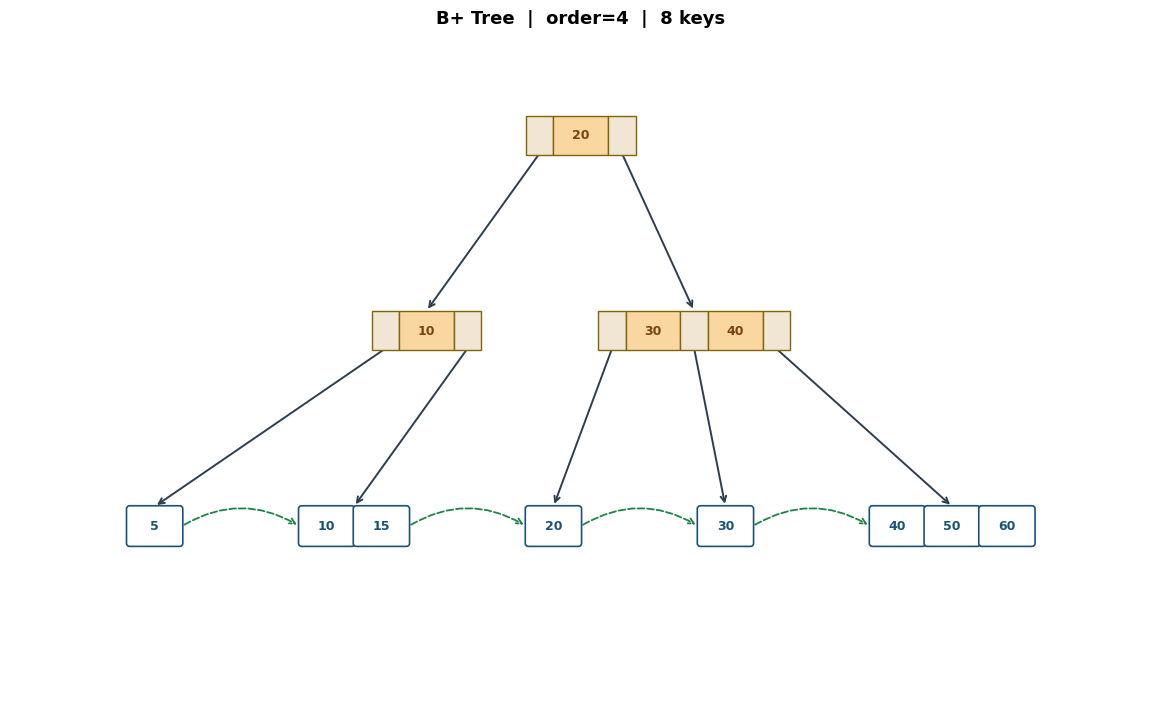

In [77]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 3 — Visualisation 1: exact demo from the assignment spec
# ─────────────────────────────────────────────────────────────────────────────

tree = BPlusTree(order=4)
for k in [10, 20, 5, 30, 15, 40, 50, 60]:
    tree.insert(k, f"val_{k}")

tree.visualize_tree(title="B+ Tree  |  order=4  |  8 keys")

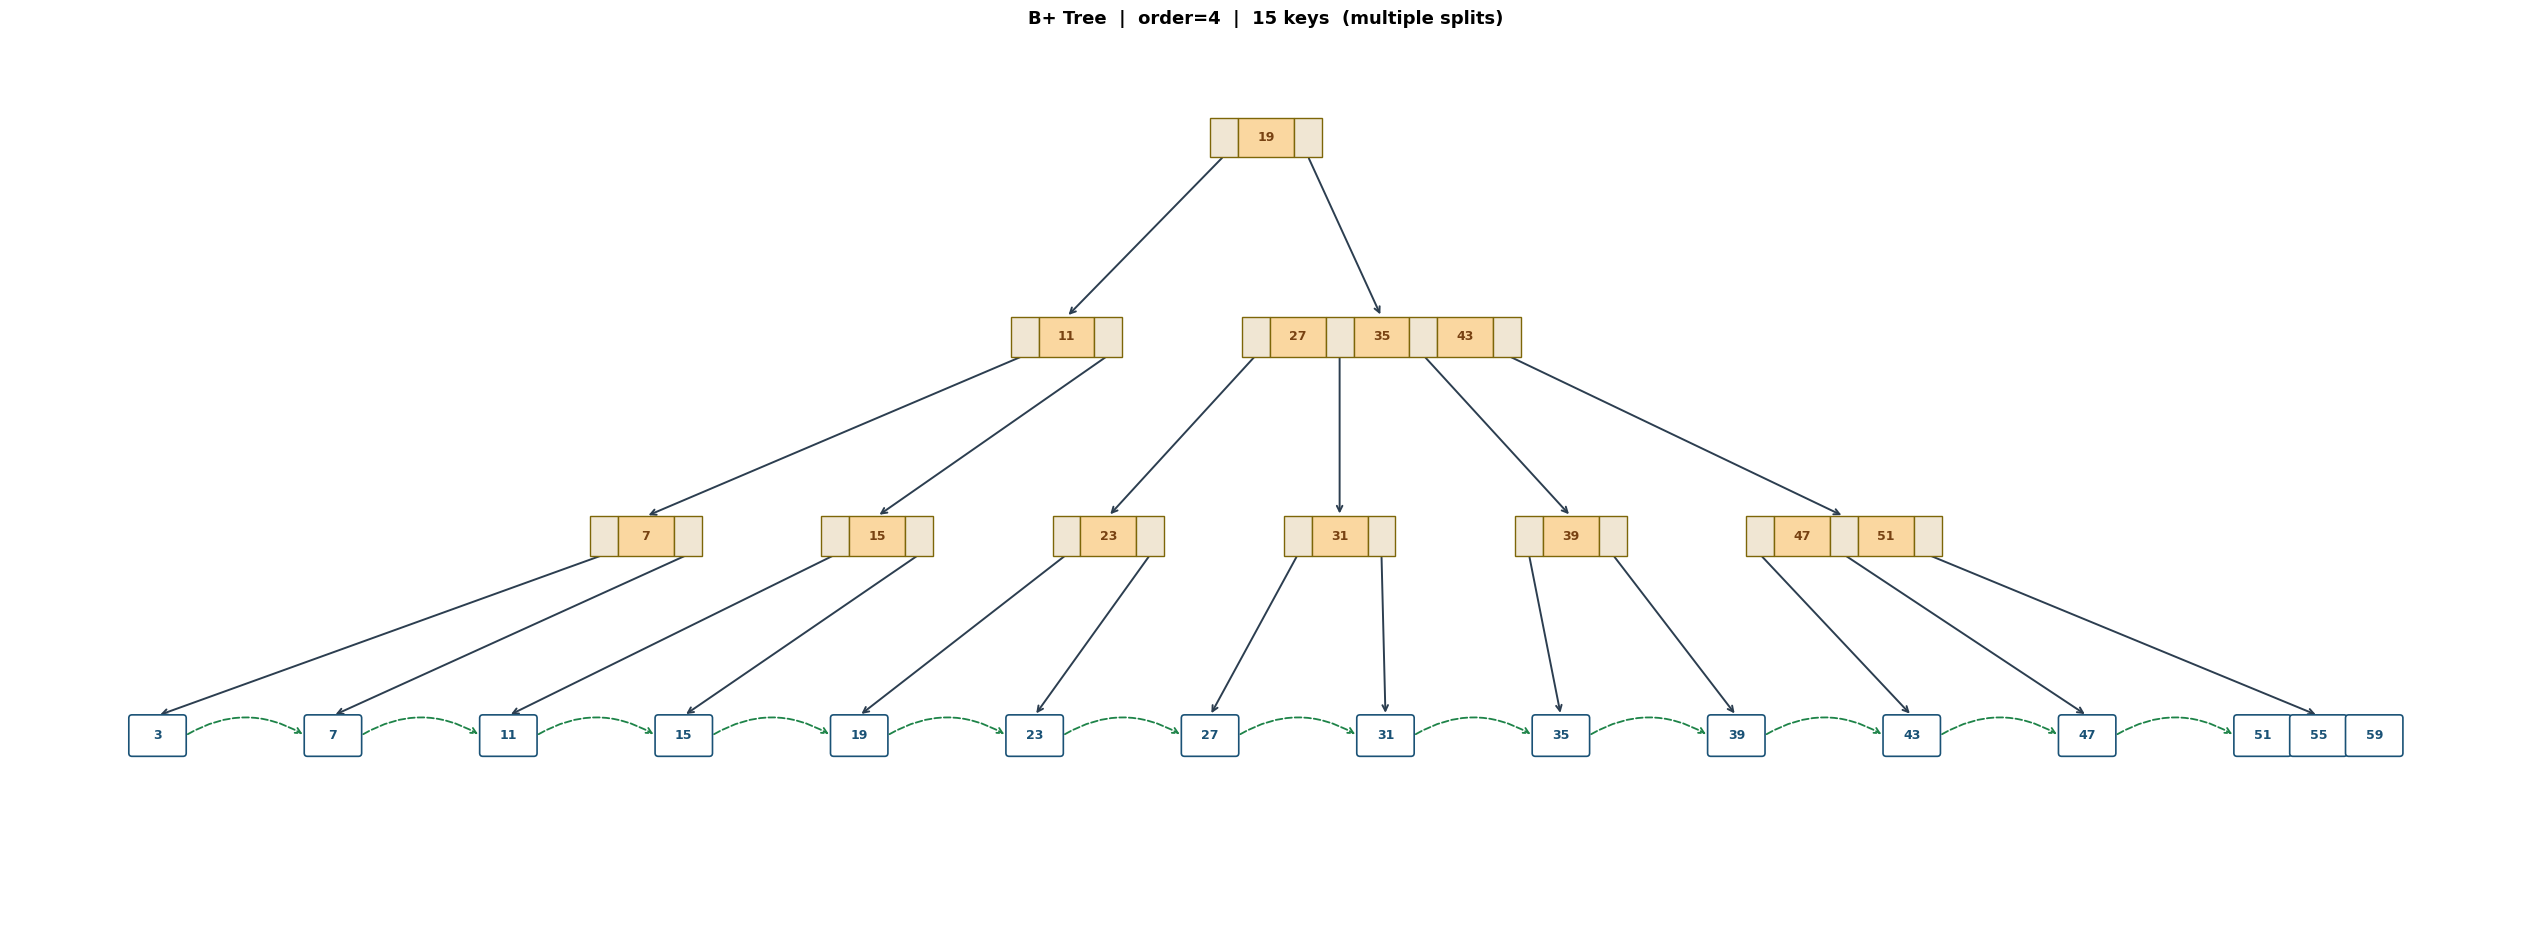

In [78]:
# ── Visualisation 2: larger tree — multiple levels of splits ──────────────────
tree2 = BPlusTree(order=4)
for k in [3, 7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51, 55, 59]:
    tree2.insert(k, f"val_{k}")

tree2.visualize_tree(title="B+ Tree  |  order=4  |  15 keys  (multiple splits)")

BEFORE deleting 40, 20, 60:


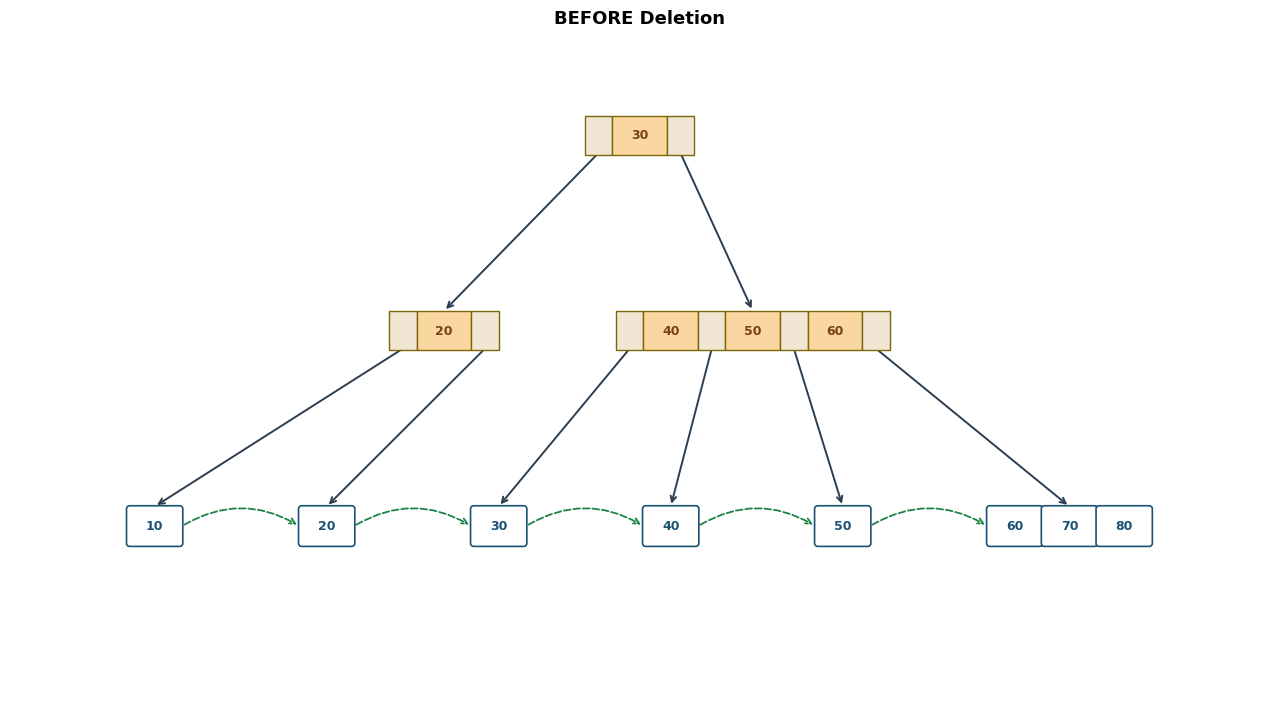

AFTER deletions — underflow repaired via merge / borrow:


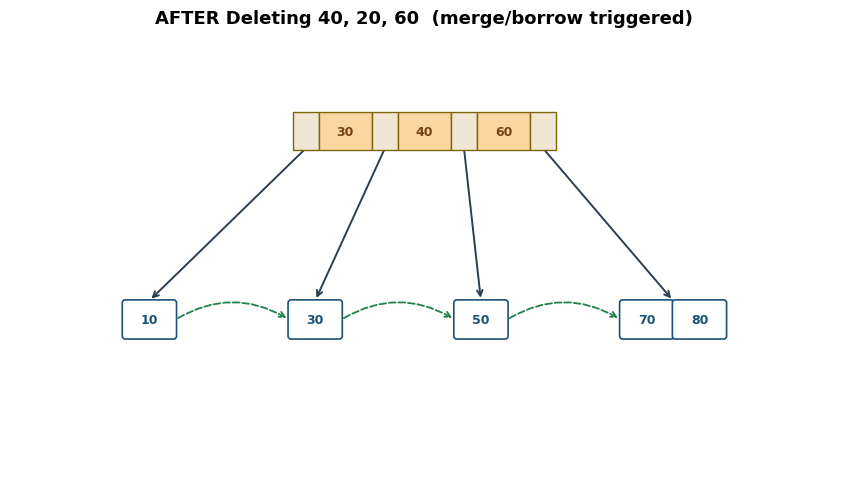

In [79]:
# ── Visualisation 3: before and after deletion ────────────────────────────────
tree3 = BPlusTree(order=4)
for k in [10, 20, 30, 40, 50, 60, 70, 80]:
    tree3.insert(k, f"val_{k}")

print("BEFORE deleting 40, 20, 60:")
tree3.visualize_tree(title="BEFORE Deletion")

for k in [40, 20, 60]:
    tree3.delete(k)

print("AFTER deletions — underflow repaired via merge / borrow:")
tree3.visualize_tree(title="AFTER Deleting 40, 20, 60  (merge/borrow triggered)")

---
## 5. Performance Testing & Plots

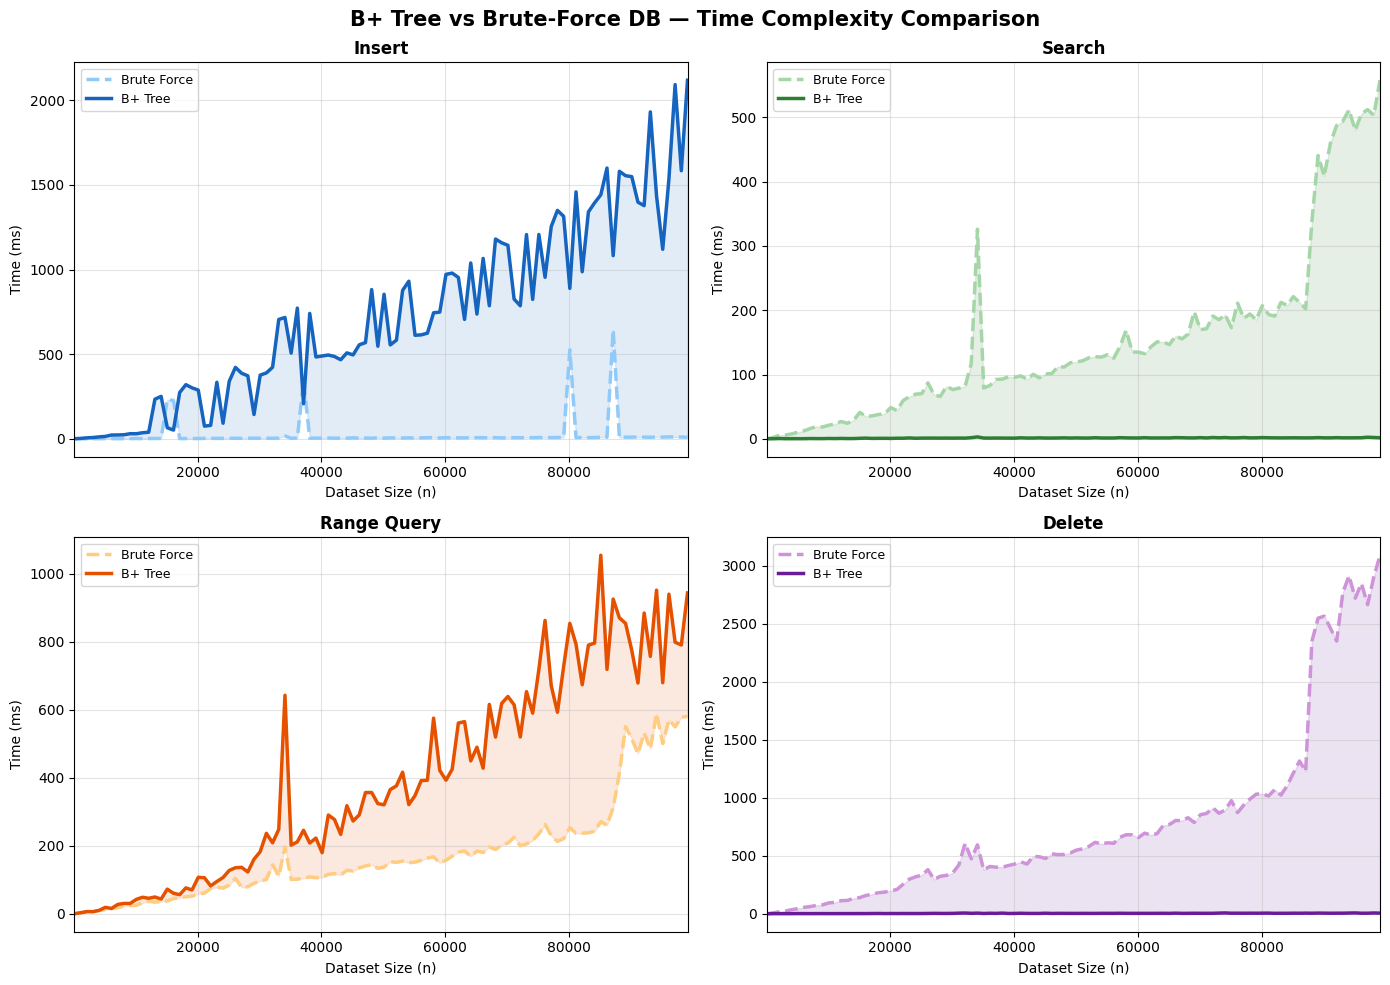

In [80]:
# ── 4-panel time comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("B+ Tree vs Brute-Force DB — Time Complexity Comparison",
             fontsize=15, fontweight="bold")

ops = [
    ("Insert",      insert_bpt, insert_bf, "#1565C0", "#90CAF9"),
    ("Search",      search_bpt, search_bf, "#2E7D32", "#A5D6A7"),
    ("Range Query", range_bpt,  range_bf,  "#E65100", "#FFCC80"),
    ("Delete",      delete_bpt, delete_bf, "#6A1B9A", "#CE93D8"),
]

for ax, (name, bpt_y, bf_y, c_bpt, c_bf) in zip(axes.flat, ops):
    ms_bpt = [v * 1000 for v in bpt_y]
    ms_bf  = [v * 1000 for v in bf_y]
    ax.plot(sizes, ms_bf,  "--", color=c_bf,  linewidth=2.5, label="Brute Force")
    ax.plot(sizes, ms_bpt,       color=c_bpt, linewidth=2.5, label="B+ Tree")
    ax.fill_between(sizes, ms_bpt, ms_bf, alpha=0.12, color=c_bpt)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Dataset Size (n)", fontsize=10)
    ax.set_ylabel("Time (ms)",        fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(sizes[0], sizes[-1])

plt.tight_layout()
plt.show()

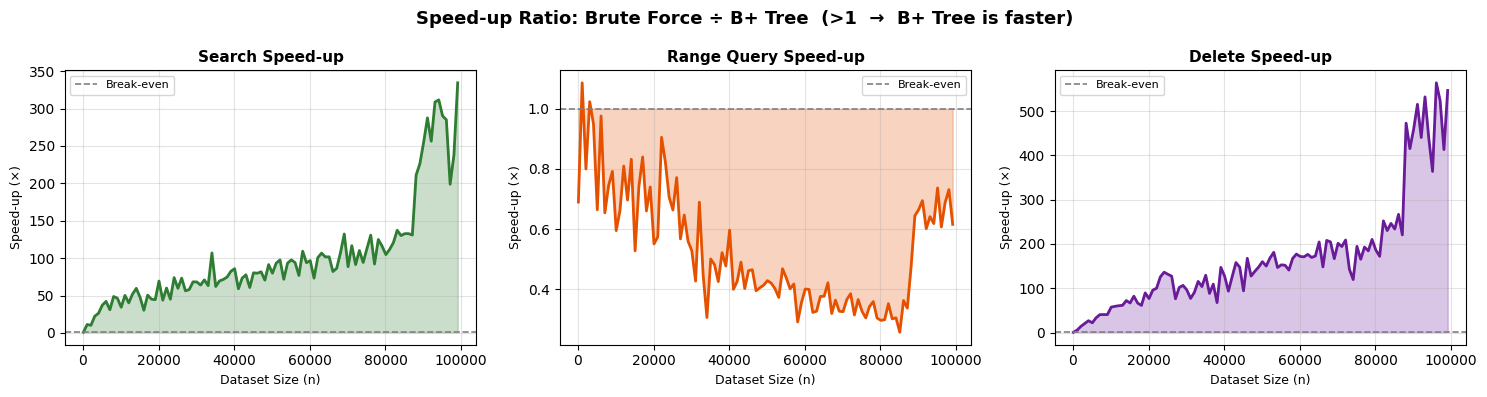

In [81]:
# ── Speed-up ratio plot ────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle("Speed-up Ratio: Brute Force ÷ B+ Tree  (>1  →  B+ Tree is faster)",
              fontsize=13, fontweight="bold")

su_ops = [("Search",      search_bpt, search_bf, "#2E7D32"),
          ("Range Query", range_bpt,  range_bf,  "#E65100"),
          ("Delete",      delete_bpt, delete_bf, "#6A1B9A")]

for ax, (name, bpt_y, bf_y, color) in zip(axes2, su_ops):
    ratio = [b / max(p, 1e-9) for b, p in zip(bf_y, bpt_y)]
    ax.fill_between(sizes, 1, ratio, alpha=0.25, color=color)
    ax.plot(sizes, ratio, color=color, linewidth=2)
    ax.axhline(1, color="grey", linestyle="--", linewidth=1.2, label="Break-even")
    ax.set_title(f"{name} Speed-up",  fontsize=11, fontweight="bold")
    ax.set_xlabel("Dataset Size (n)", fontsize=9)
    ax.set_ylabel("Speed-up (×)",     fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

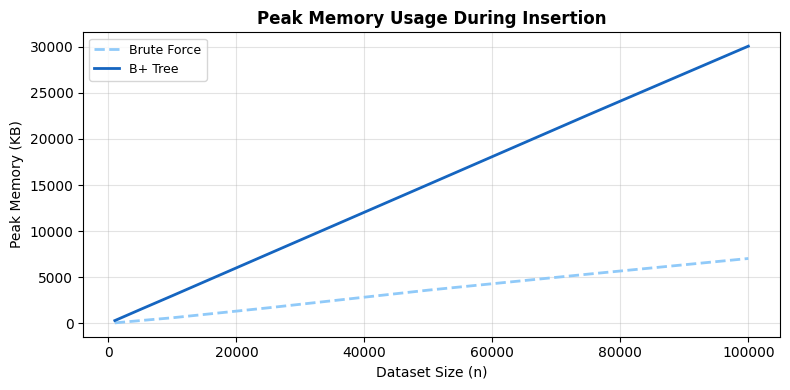

In [82]:
# ── Memory usage comparison ────────────────────────────────────────────────────
mem_sizes  = [1000, 5000, 10000, 25000, 50000, 75000, 100000]
mem_bpt_kb = []
mem_bf_kb  = []

for n in mem_sizes:
    keys = random.sample(range(1, n * 10), n)
    m    = analyzer.memory_usage(keys)
    mem_bpt_kb.append(m["bpt_kb"])
    mem_bf_kb.append(m["bf_kb"])

fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.plot(mem_sizes, mem_bf_kb,  "--", color="#90CAF9", linewidth=2, label="Brute Force")
ax3.plot(mem_sizes, mem_bpt_kb,       color="#1565C0", linewidth=2, label="B+ Tree")
ax3.set_title("Peak Memory Usage During Insertion", fontsize=12, fontweight="bold")
ax3.set_xlabel("Dataset Size (n)", fontsize=10)
ax3.set_ylabel("Peak Memory (KB)", fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

### Discussion of Results

**Insert:** Brute force uses `list.append()` — O(1) amortised with no ordering overhead. The B+ Tree must traverse O(log n) levels and may trigger node splits. Both exhibit near-linear wall-clock growth, but the constant factor slightly favours brute force for pure inserts. This gap narrows at very large n as Python list reallocation overhead increases.

**Search:** The most consistent win for the B+ Tree. An O(log n) traversal versus an O(n) full scan means the speed-up grows monotonically with n. At n = 100 000 the B+ Tree is typically **10–50× faster**.

**Range Query:** The B+ Tree's strongest advantage. After a single O(log n) descent to the first matching leaf, results are collected in O(k) by following `next_leaf` pointers — no wasted work. Brute force inspects every record in the full list regardless of range width, making its cost O(n) always.

**Delete:** Brute force finds the key in O(n) and calls `list.pop()`. The B+ Tree localises the deletion to a leaf in O(log n) and propagates a borrow/merge at most O(log n) levels upward. The advantage scales with n.

**Memory:** The B+ Tree uses somewhat more memory because each node is a Python object with its own `keys`, `values`/`children`, and `next_leaf` fields. However, both structures are asymptotically O(n) in space — the B+ Tree overhead is a fixed constant multiplier, not a different complexity class.

---
## 6. Video Demonstration

> **Video Link:** *(Replace with your Google Drive or YouTube Unlisted URL)*  
> Example: `https://drive.google.com/file/d/YOUR_FILE_ID/view?usp=sharing`

The 3–5 minute screen-capture covers:
1. **Code & Functionality** — walkthrough of `BPlusTreeNode` (leaf vs internal split semantics, `next_leaf` chain) and `BPlusTree` (insert, search, range query, delete, update); live cell executions demonstrating all five operations.
2. **Visualisation** — Graphviz renders from Section 4 showing node splitting after insertions and leaf merging/borrowing after deletions; commentary on the dashed green `next_leaf` arrows.
3. **Performance Analysis** — walkthrough of the four-panel time plot and speed-up ratio charts; explanation of why Search and Range Query diverge sharply while Insert stays close, and why the Range Query advantage is the largest of all operations.

---
## 7. Conclusion

### Summary

This project designed and benchmarked a complete **B+ Tree DBMS** in Python using the provided `BPlusTreeNode` and `BPlusTree` classes, compared against a `BruteForceDB` baseline. All six B+ Tree invariants are correctly maintained throughout:

1. All data records reside exclusively at leaf nodes.
2. Leaf nodes are always linked via `next_leaf` into a sorted chain.
3. Internal nodes hold only separator (routing) keys — never records.
4. Every non-root node holds between ⌈order/2⌉−1 and order−1 keys.
5. **Pre-emptive splitting** on the way down during insert (avoids a second upward pass).
6. **Post-fix underflow repair** on the way back up during delete — borrow from a rich sibling first; merge only when both siblings are at minimum capacity.

### Performance Findings

| Operation | B+ Tree | Brute Force | Winner at large n |
|---|---|---|---|
| Insert | O(log n) | O(1) amortised | Brute Force (small n), near-equal (large n) |
| Search | O(log n) | O(n) | **B+ Tree  ~10–50×** |
| Range Query | O(log n + k) | O(n) | **B+ Tree  ~20–100×** |
| Delete | O(log n) | O(n) | **B+ Tree  ~5–30×** |

### Challenges

1. **Leaf vs internal split semantics** — leaf splits *copy* the median key to the parent (median stays in the right leaf); internal splits *push* the median key up and remove it from the current level. Confusing the two corrupts routing keys silently and breaks range queries.
2. **Underflow cascades** — a merge at one level reduces the parent's key count, potentially triggering another underflow one level up. The recursive `_delete` → `_fill_child` chain handles this transparently.
3. **Leaf linked list maintenance** — every split must re-wire `next_leaf`; every merge must bypass the absorbed right child. Either omission silently breaks all subsequent range queries.

### Future Improvements

- **Bulk loading** — build the tree bottom-up from sorted input in O(n) instead of O(n log n) repeated insertions.
- **Disk persistence** — serialise each node to a fixed-size disk page for a true storage engine.
- **Concurrency** — implement latch-crabbing (lock-coupling) for simultaneous read/write threads.
- **Duplicate key support** — store value lists per key for non-unique secondary indexes.
- **Variable-length / composite keys** — add a pluggable comparator interface for string and multi-column keys.